# Fashion Mnist

### Get Dataset

In [20]:
import os
import kagglehub

os.environ["KAGGLE_USERNAME"] = "yiannipapazis"
os.environ["KAGGLE_KEY"] = "ea02009ed2a4305c52812b4181b3f6f1"

#kagglehub.login()


print(f"Authenticated as {os.environ.get("KAGGLE_USERNAME")}")
print(f"Authenticated as {os.environ.get("KAGGLE_KEY")}")

path = kagglehub.dataset_download("zalando-research/fashionmnist")

Authenticated as yiannipapazis
Authenticated as ea02009ed2a4305c52812b4181b3f6f1


100%|██████████| 68.8M/68.8M [00:02<00:00, 31.9MB/s]

Extracting files...


### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input
from keras.optimizers import Adam
from keras.callbacks import TensorBoard
num_classes = 10
epochs = 20

### Dataframe

In [21]:
os.listdir(path)

['t10k-images-idx3-ubyte',
 'fashion-mnist_test.csv',
 't10k-labels-idx1-ubyte',
 'train-labels-idx1-ubyte',
 'train-images-idx3-ubyte',
 'fashion-mnist_train.csv']

In [22]:
train_df = pd.read_csv(f"{path}/fashion-mnist_train.csv")
test_df = pd.read_csv(f"{path}/fashion-mnist_test.csv")

Lets' explore the train and test data...

In [23]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Convert the dataframes into numpy arrays of float32 type which is the acceptable form for tensorflow and keras

In [25]:
train_data = np.array(train_df, dtype='float32')
test_data = np.array(test_df, dtype='float32')


In [26]:
x_train = train_data[:,1:]/255
y_train = train_data[:,0]

x_test = test_data[:,1:]/255
y_test = test_data[:,0]

Now we are gonna split the training data into validation and actual training data for training the model and testing it using the validation set. This is achieved using the train_test_split method of scikit learn library.

In [27]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size=0.2, random_state=12345)

Now let us visualise the some samples after the resize of the data which need to be ready for training the network.

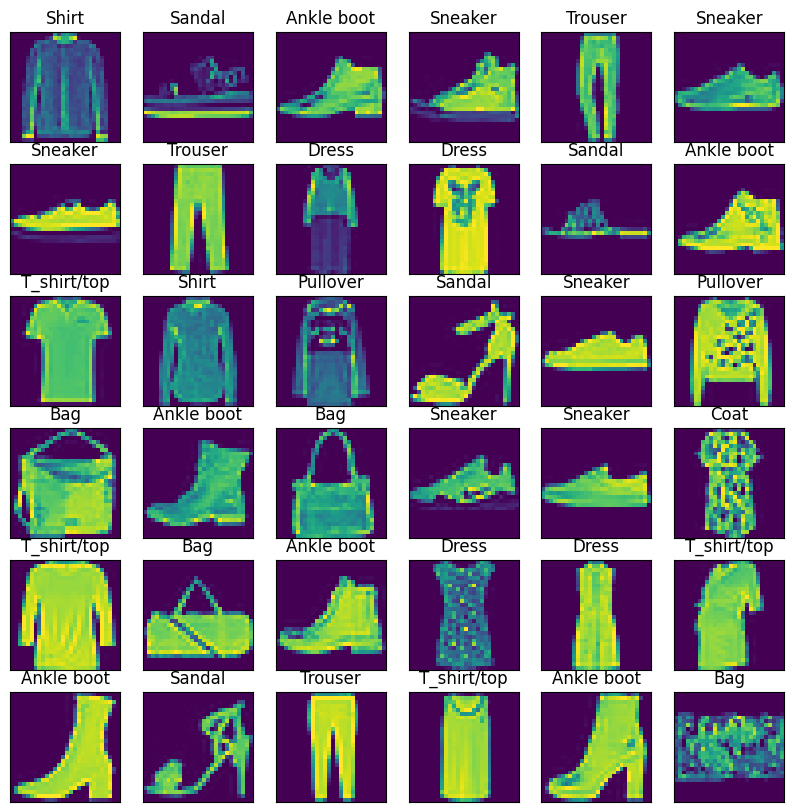

In [28]:
class_names = ['T_shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(36):
    plt.subplot(6, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape((28, 28)))
    label_index = int(y_train[i])
    plt.title(class_names[label_index])
plt.show()

Labels each training and test example is assigned to one of the following labels as shown below:

- 0 - T_shirt/top
- 1 - Trouser
- 2 - Pullover
- 3 - Dress
- 4 - Coat
- 5 - Sandal
- 6 - Shirt
- 7 - Sneaker
- 8 - Bag
- 9 - Ankle boot

I think the best way is to visualise the above 10 types of classes to get a feel of what these items look like. So let us visualise...

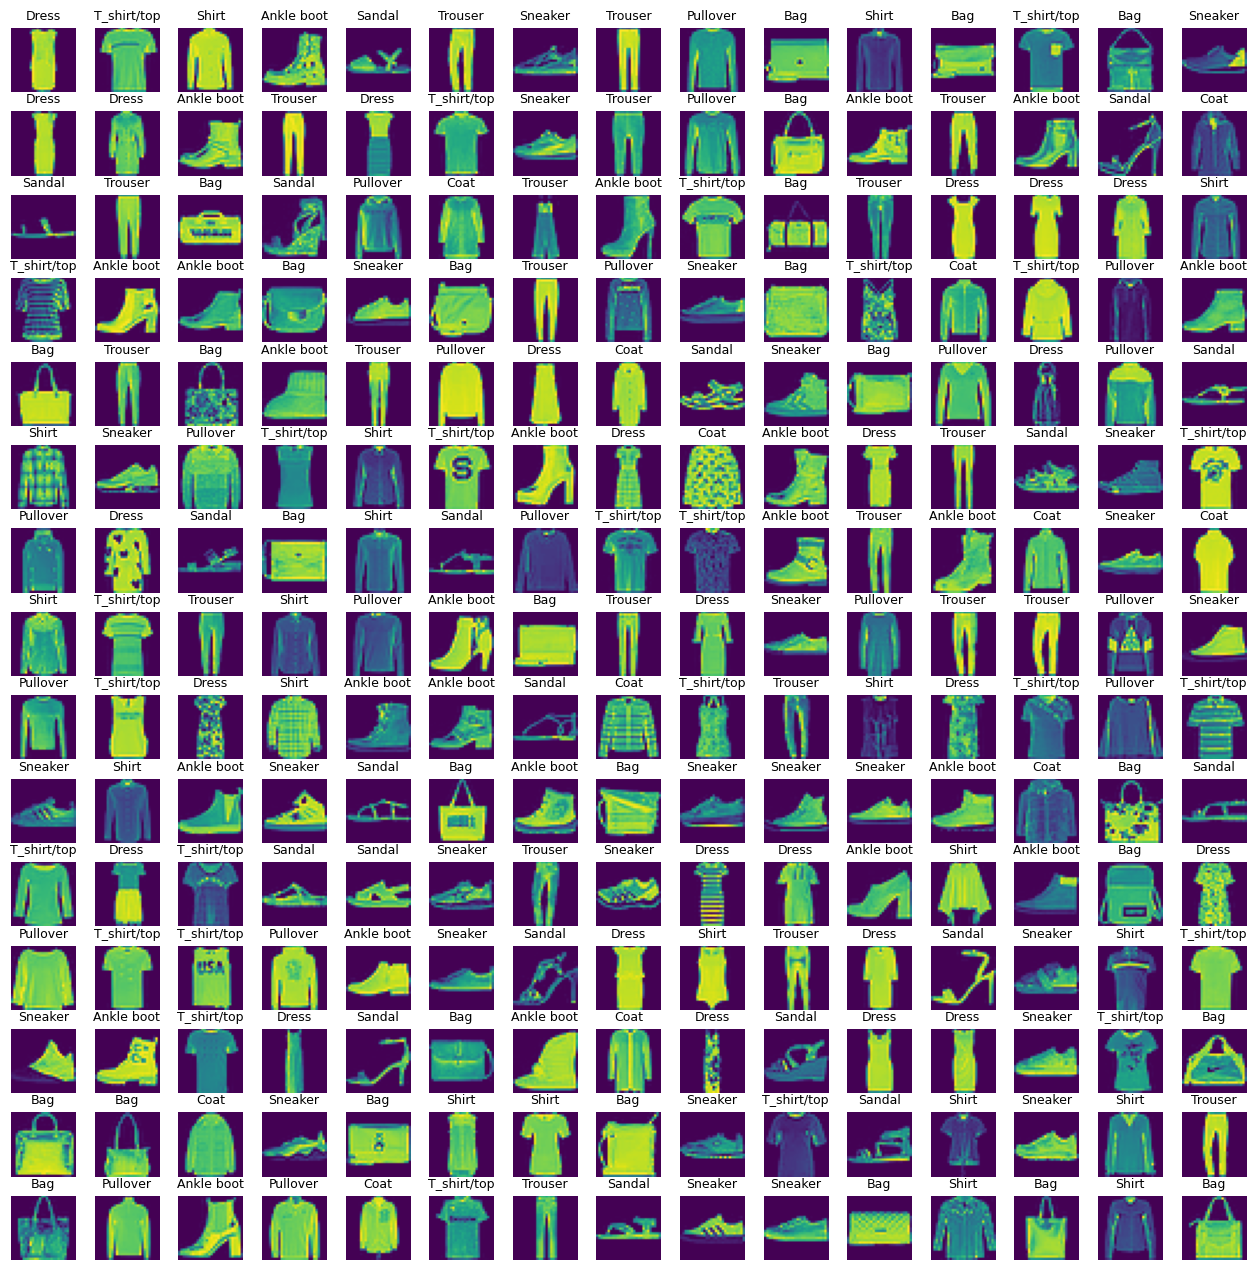

In [29]:
w_grid = 15
l_grid = 15

fig, axes = plt.subplots(l_grid, w_grid, figsize=(16,16))
axes = axes.ravel() # Flatten the 15 x 15 matrix into 255 array
n_train = len(train_data)

# Select a random number from 0 to n_train
for i in np.arange(0, w_grid * l_grid): # Create evenly spaced variables
    index = np.random.randint(0, n_train)
    axes[i].imshow(train_data[index, 1:].reshape(28, 28))
    label_index = int(train_data[index, 0])
    axes[i].set_title(class_names[label_index], fontsize=9)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.3)

### Create the Convolutional Neural Networks (CNN)

- Define model
- Compile model
- Train model

First of all let us define the shape of the image before we define the model. Defined the shape of the image as 3D with rows and columns and 1 for the 3D Visualisation.

In [32]:
image_rows = 28
image_cols = 28
batch_size = 4096
image_shape = (image_rows, image_cols, 1)

Now we need to do more formating on the x_train, x_test and x_validate sets.

In [33]:
x_train = x_train.reshape(x_train.shape[0], *image_shape)
x_test = x_test.reshape(x_test.shape[0], *image_shape)
x_validate = x_validate.reshape(x_validate.shape[0], *image_shape)


#### Define the model
The first layer in the model network, `keras.layers.Flatten`, transform the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one_dimensional array (of 28 * 28 = 784). This layer unstacks rows of pixels in the image and lining them up and has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two `keras.layers.Dense` layers. These are densely connected, or fully connected, neural layers. The first Dense layers has 32 nodes (or neurons). The second (and last) layer is a 10-node softmax layer that returns and array of 10 probability scores that sum to 1. Each node contains a score that indicates the probability that the current image belongs to one of the 10 classes.

In [34]:
cnn_model = Sequential([
    Input(image_shape),
    Conv2D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

#### Compile the model

Before the odel is ready for training, it needs a few more settings. These are added during the model's compile step:
- Loss function -- This measure how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction. Here we will use `spare_categorical_crossentropy`
- Optimizer - This is how the model is updated based on the date it see and it's loss function.
- Metrics - Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified.

In [35]:
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

### Train the Model

Training the neural network model requires the following steps:
- Feeding the training data to the model. In this example, the training data is the x_train and y_train arrays.
- The model learns to associate images and labels.
- You ask the model to make predictions about a test set - in this example, the x_test array. Verify that the prediction match the labels from the y_test array.
To start training, call the `model.fit` method - so called because it 'fits' the model to the training data:

In [39]:
history = cnn_model.fit(
    x_train,
    y_train,
    batch_size=4096,
    epochs=75,
    verbose=1,
    validation_data=(x_validate, y_validate)
)

Epoch 1/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.3128 - loss: 2.0138 - val_accuracy: 0.6652 - val_loss: 1.1170
Epoch 2/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6857 - loss: 0.9788 - val_accuracy: 0.7441 - val_loss: 0.7081
Epoch 3/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7587 - loss: 0.6802 - val_accuracy: 0.7850 - val_loss: 0.5998
Epoch 4/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7911 - loss: 0.5898 - val_accuracy: 0.8115 - val_loss: 0.5340
Epoch 5/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8110 - loss: 0.5378 - val_accuracy: 0.8250 - val_loss: 0.4991
Epoch 6/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8264 - loss: 0.4979 - val_accuracy: 0.8368 - val_loss: 0.4650
Epoch 7/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8386 - loss: 0.4640 - val_accuracy: 0.8453 - val_loss: 0.4417
Epoch 8/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8459 - loss: 0.4420 - val_accuracy: 0.8497 - val_loss:

#### Save the Model

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


cnn_model.save("MyDrive/Models/fashion_mnist_model.keras")

Mounted at /content/gdrive
cp: cannot stat 'fashion_mnist_model.keras': No such file or directory


### Evaluate the Model

#### Evaluate the Training

NameError: name 'history' is not defined

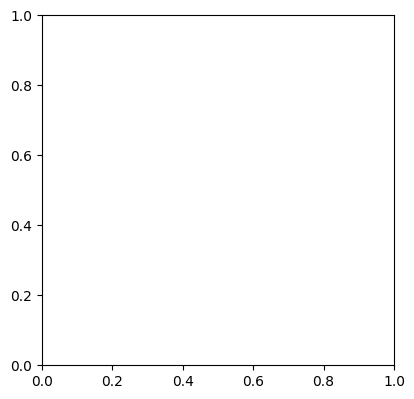

In [16]:
plt.figure(figsize=(10,10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')


plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.title("Train - Accuracy")

#### Load the Model

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

cnn_model = keras.models.load_model("/content/gdrive/MyDrive/Models/fashion_mnist_model.keras")

In [37]:
score = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss : {score[0]:>8f}')
print(f"Test Accuracy : {score[1]:>8f}")

Test Loss : 2.319863
Test Accuracy : 0.030300


#### Results
Let's plot training and validation accuracy as well as loss

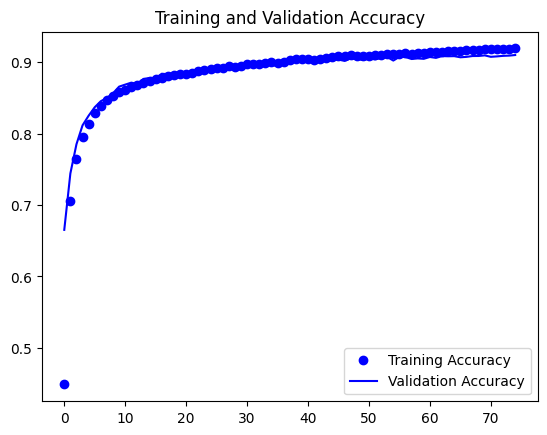

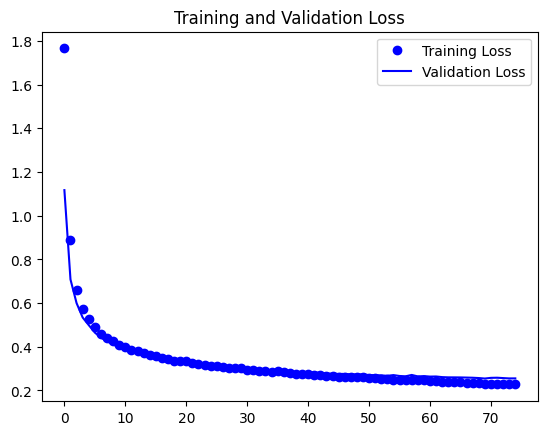

In [55]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

#### Classification Report
We can summarize the performance of our classifiers as follows...

In [38]:
predictions = cnn_model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)

# Get the indices to be plotted
y_true = test_df.iloc[:, 0]
correct = np.nonzero(predicted_classes==y_true)[0]


incorrect = np.nonzero(predicted_classes!=y_true)[0]
from sklearn.metrics import classification_report
target_names = ["Class {}".format(class_names[i]) for i in range (num_classes)]
print(classification_report(y_true, predicted_classes, target_names=target_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
                   precision    recall  f1-score   support

Class T_shirt/top       0.05      0.23      0.08      1000
    Class Trouser       0.00      0.00      0.00      1000
   Class Pullover       0.01      0.00      0.00      1000
      Class Dress       0.03      0.00      0.01      1000
       Class Coat       0.00      0.00      0.00      1000
     Class Sandal       0.26      0.02      0.03      1000
      Class Shirt       0.07      0.01      0.02      1000
    Class Sneaker       0.02      0.01      0.01      1000
        Class Bag       0.56      0.01      0.01      1000
 Class Ankle boot       0.01      0.02      0.01      1000

         accuracy                           0.03     10000
        macro avg       0.10      0.03      0.02     10000
     weighted avg       0.10      0.03      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


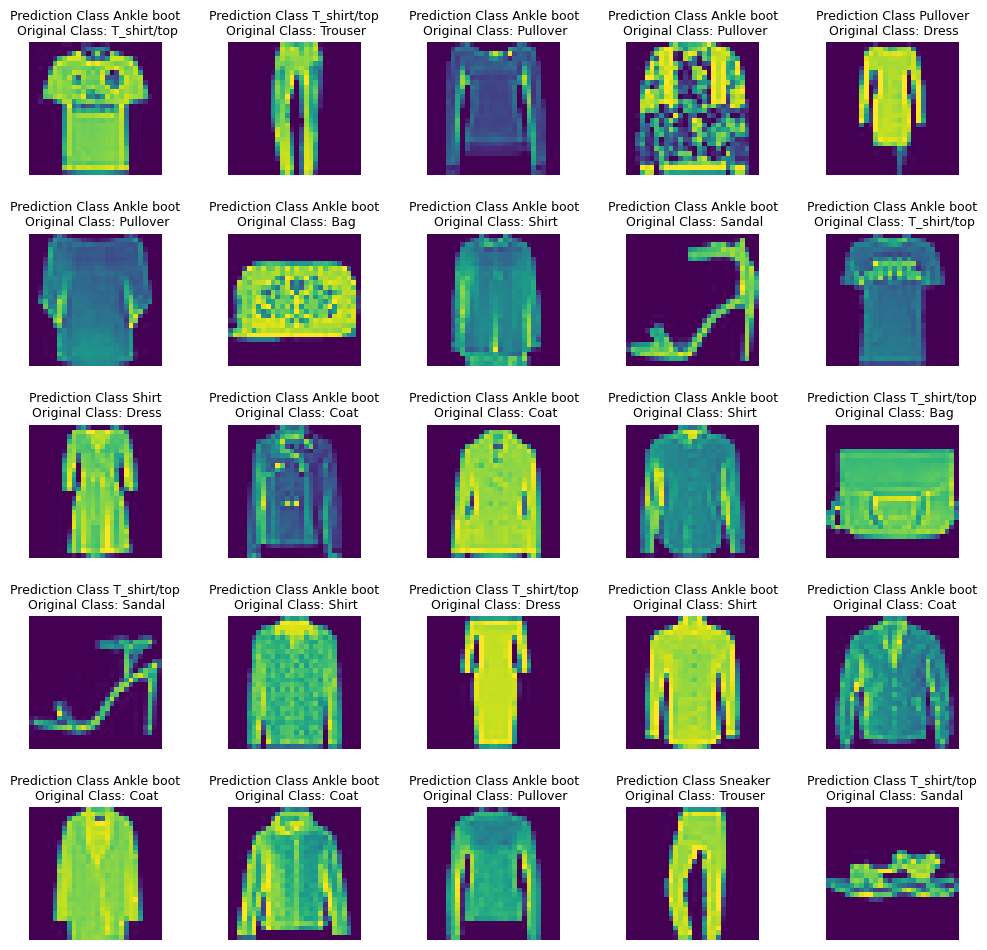

In [49]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):  
    axes[i].imshow(x_test[i].reshape(28,28))
    axes[i].set_title(f"Prediction Class {class_names[predicted_classes[i]]}\n Original Class: {class_names[int(y_test[i])]}")
    axes[i].title.set_size(9)
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)